In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("creditcard.csv")

df.info()                  # column types, nulls
df.describe()              # stats for Amount, Time, V1-V28
df['Class'].value_counts() # 0 = normal, 1 = fraud — see the imbalance

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

,count
Class,
0,284315
1,492


In [9]:
# 1. How rare is fraud, really?
fraud_pct = df['Class'].value_counts(normalize=True) * 100
print(fraud_pct)  # fraud is usually ~0.17% of all transactions

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


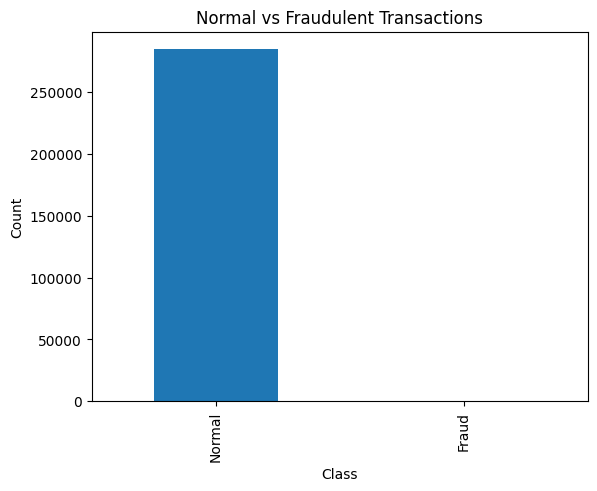

In [10]:
# 2. Bar chart: fraud vs. normal counts
df['Class'].value_counts().plot(kind='bar', title='Normal vs Fraudulent Transactions')
plt.xticks([0, 1], ['Normal', 'Fraud'])
plt.ylabel('Count')
plt.show()

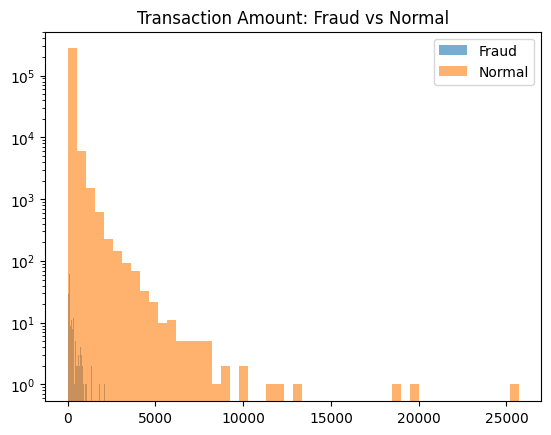

In [11]:
# 3. Does fraud happen at different transaction amounts?
fraud = df[df['Class'] == 1]
normal = df[df['Class'] == 0]

plt.hist(fraud['Amount'], bins=50, alpha=0.6, label='Fraud')
plt.hist(normal['Amount'], bins=50, alpha=0.6, label='Normal')
plt.legend()
plt.title('Transaction Amount: Fraud vs Normal')
plt.yscale('log')  # fraud counts are tiny, log scale makes it visible
plt.show()

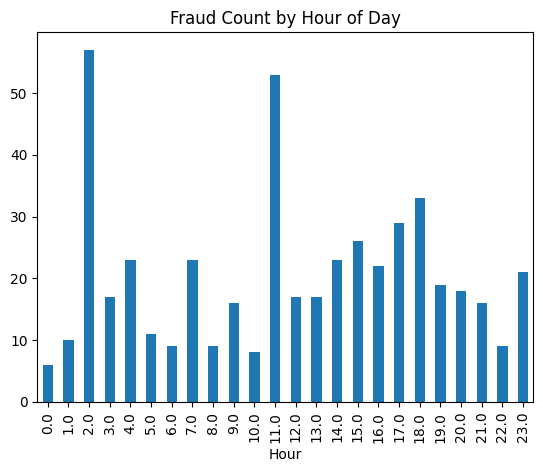

In [12]:
# 4. Does fraud cluster at certain times? (Time = seconds since first transaction)
df['Hour'] = (df['Time'] // 3600) % 24
fraud_by_hour = df[df['Class'] == 1]['Hour'].value_counts().sort_index()
fraud_by_hour.plot(kind='bar', title='Fraud Count by Hour of Day')
plt.show()

In [13]:
# 5. Which features correlate most with fraud?
correlations = df.corr()['Class'].sort_values(ascending=False)
print(correlations.head(6))   # top positive correlations
print(correlations.tail(6))   # top negative correlations

Class    1.000000
V11      0.154876
V4       0.133447
V2       0.091289
V21      0.040413
V19      0.034783
Name: Class, dtype: float64
V3    -0.192961
V16   -0.196539
V10   -0.216883
V12   -0.260593
V14   -0.302544
V17   -0.326481
Name: Class, dtype: float64


Capture: what % of transactions are fraud, the amount pattern you found (fraud tends to skew toward smaller amounts — good insight for a blog), any time-of-day pattern, and which anonymized features (V-something) correlate most. This becomes your blog's backbone, same as last time.

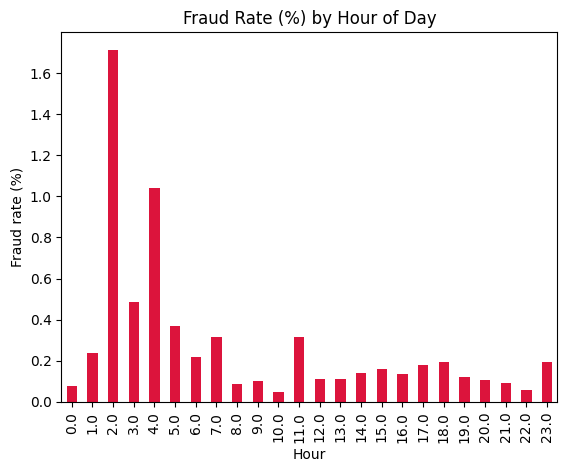

Hour
2.0     1.712740
4.0     1.041195
3.0     0.486827
5.0     0.367893
7.0     0.317548
11.0    0.314428
1.0     0.236967
6.0     0.219459
18.0    0.193673
23.0    0.191991
17.0    0.179389
15.0    0.157949
14.0    0.138805
16.0    0.133714
19.0    0.121414
13.0    0.110641
12.0    0.110246
20.0    0.107424
9.0     0.101023
21.0    0.090380
8.0     0.087583
0.0     0.077973
22.0    0.058286
10.0    0.048199
dtype: float64


In [14]:
# 6. Fraud RATE by hour (not just count) — normalizes for the fact that
# some hours simply have more total transactions than others
hourly_totals = df.groupby('Hour').size()
hourly_fraud = df[df['Class'] == 1].groupby('Hour').size()

fraud_rate_by_hour = (hourly_fraud / hourly_totals * 100).fillna(0)

fraud_rate_by_hour.plot(kind='bar', title='Fraud Rate (%) by Hour of Day', color='crimson')
plt.ylabel('Fraud rate (%)')
plt.xlabel('Hour')
plt.show()

print(fraud_rate_by_hour.sort_values(ascending=False))